In [122]:
import numpy as np
import os
import h5py
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jaxdem.analysis import LagBinsPseudoLog, evaluate_binned
from jaxdem.analysis.kernels import msd_kernel

def load_arrs(path):
    with h5py.File(path, 'r') as f:
        return {name: f[name][()] for name in f.keys()}

def get_relaxation_time(f, t):
    tau = np.interp(1 / np.e, f[::-1], t[::-1])
    if not np.min(f) < 1 / np.e:
        return np.nan
    return tau

def get_diffusion_coeff(m, t, dim=2, scale=1):
    mask = t < t.max() / (10 * scale)
    c = np.mean(np.log10(m) - np.log10(t))
    return (10 ** c) / (2 * dim)

def quaternion_to_orientation(q_w, q_xyz, ref=None):
    """(T, N, 1), (T, N, 3) -> (T, N, 3)"""
    if ref is None:
        ref = jnp.array([0.0, 0.0, 1.0])
    T = jnp.cross(q_xyz, ref)
    B = jnp.cross(q_xyz, T)
    return ref + 2.0 * (q_w * T + B)

def c1_kernel(arrays, t0, t1):
    """C_1(t) = <e(t0) . e(t1)>"""
    e0 = arrays["orientation"][t0]
    e1 = arrays["orientation"][t1]
    cos_theta = jnp.sum(e0 * e1, axis=-1)
    return jnp.mean(cos_theta, axis=-1)

def c2_kernel(arrays, t0, t1):
    """C_2(t) = <P_2(e(t0) . e(t1))>"""
    e0 = arrays["orientation"][t0]
    e1 = arrays["orientation"][t1]
    cos_theta = jnp.sum(e0 * e1, axis=-1)
    return jnp.mean(0.5 * (3.0 * cos_theta**2 - 1.0), axis=-1)

def msad_bounded_geodesic_kernel(arrays, t0, t1):
    e0 = arrays["orientation"][t0]
    e1 = arrays["orientation"][t1]
    cos_theta = jnp.sum(e0 * e1, axis=-1)
    return jnp.mean(jnp.arccos(cos_theta) ** 2, axis=-1)

def msad_unbounded_kernel(arrays, t0, t1):
    phi0 = arrays["phi"][t0]  # (N_clumps, 3)
    phi1 = arrays["phi"][t1]
    dphi = phi1 - phi0
    return jnp.mean(jnp.sum(dphi**2, axis=-1), axis=-1)

phi-0.5.h5
0.04584394920411947 0.002430915336871898 0.001324930246005213 1.6351004404498923 nan
8.877991887657995e-05
phi-0.4.h5
0.04568009553494973 0.0025597017168307186 0.001375090059848204 1.6116214449597253 nan
5.4031803475159606e-05
phi-0.45.h5
0.04355789300739648 0.0024614486399413852 0.0013263941775894619 1.6166018937787556 nan
7.299681207813624e-05
phi-0.55.h5
0.040232663715801496 0.002298964028899306 0.001298875513871823 1.6949488955166863 nan
0.00011500211077097787
phi-0.65.h5
0.03609963700800232 0.001680740303725135 0.0010765583193652532 1.9215788131798943 nan
0.00023932322945909514
phi-0.6.h5
0.04152886553643478 0.002100631916829246 0.0012376871075826632 1.7675925482235795 nan
0.00016165973562180208


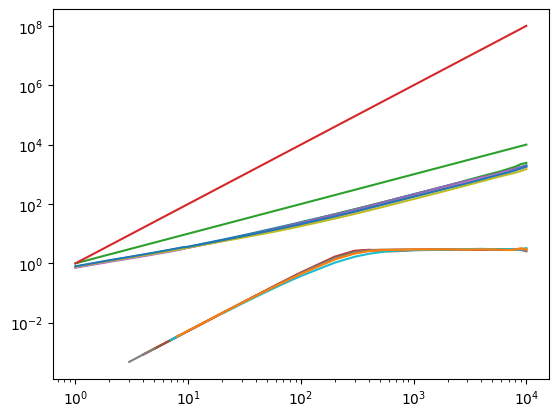

: 

In [ ]:
root = os.path.join('data', 'asperity_radius-0.2-nv-43')
for fname in os.listdir(root):
    print(fname)

    dens = float(fname.split('-')[-1].split('.h5')[0])

    dt = 1e-2
    data = load_arrs(os.path.join(root, fname))

    step_ids = data['step_ids']
    pos = data['pos']
    phi = data['phi_cumulative']
    q_w = data['q_w']
    q_xyz = data['q_xyz']

    e_major = quaternion_to_orientation(q_w, q_xyz, ref=jnp.array([0.0, 0.0, 1.0]))
    e_minor = quaternion_to_orientation(q_w, q_xyz, ref=jnp.array([1.0, 0.0, 0.0]))

    T = pos.shape[0]
    bins = LagBinsPseudoLog(
        T,
        dt_min=1,
        dt_max=int(step_ids[-1] - step_ids[0]),
        timestep=step_ids,
    )
    tau_steps = bins.values()
    t = tau_steps * float(dt)

    c1_major = evaluate_binned(c1_kernel, {"orientation": e_major}, bins).mean
    c1_minor = evaluate_binned(c1_kernel, {"orientation": e_minor}, bins).mean
    c2_major = evaluate_binned(c2_kernel, {"orientation": e_major}, bins).mean
    c2_minor = evaluate_binned(c2_kernel, {"orientation": e_minor}, bins).mean

    c1_tau = get_relaxation_time(c1_major, t)  # exp(-2 D_r t)
    c2_tau = get_relaxation_time(c2_major, t)  # exp(-6 D_r t)

    # plt.plot(t, c1_major)
    # plt.plot(t, c1_minor)
    # plt.plot(t, c2_major)
    # plt.plot(t, c2_minor)
    # plt.xscale('log')

    msd = evaluate_binned(msd_kernel, {"pos": pos}, bins).mean
    D_t = get_diffusion_coeff(msd, t, dim=3)
    
    # plt.plot(t, msd)
    # plt.plot(t, t * D_t * 3 * 2)
    # plt.xscale('log')
    # plt.yscale('log')

    msad = evaluate_binned(msad_unbounded_kernel, {"phi": phi}, bins).mean
    D_r = get_diffusion_coeff(msad, t, dim=3)
    
    plt.plot(t, msad)
    # plt.plot(t, t * D_r * 3 * 2)

    msad_geodesic = evaluate_binned(msad_bounded_geodesic_kernel, {"orientation": e_major}, bins).mean
    D_r_geodesic = get_diffusion_coeff(msad_geodesic, t, dim=3)
    
    plt.plot(t, msad_geodesic)

    print(D_r, 1 / (2 * c1_tau), 1 / (6 * c2_tau), c1_tau / c2_tau, D_r_geodesic)

    te = data['pe'] + data['ke'] + data['ke_r']
    print(np.std(te) / np.mean(te))

    # GET THE NAIVE MSAD

plt.xscale('log')
plt.yscale('log')

plt.plot(t, t)
plt.plot(t, t ** 2)